### Load data first

In [2]:
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import time
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

from tqdm import tqdm
from datetime import datetime

### Setup Parameters

In [4]:
DATASET = "KGRR"
MODEL_NAME = "ours"

MAX_RADIUS = 120
NUM_RADII = 4
NUM_SECTORS = 8
DENSITY = 0.05

MAX_VELOCITY = 200
SHAPE_DIFF_WEIGHT = 0.4         # weights of the shape vector difference in the cost function, this will sum with spatial distance weight to 1.0

RADII = np.linspace(start=MAX_RADIUS/NUM_RADII, stop=MAX_RADIUS, num=NUM_RADII, dtype=int).tolist()

In [3]:
from src.preprocessing import read_numpy_grid, nexrad_numpy_preprocessing_pipeline

SOURCE_PATH = f"data/numpy_grid/{DATASET}"
img_paths = [os.path.join(SOURCE_PATH, img_name) for img_name in sorted(os.listdir(SOURCE_PATH)) if img_name.endswith('.npy')]

dbz_maps: list[tuple[np.ndarray, datetime]] = []

for path in tqdm(img_paths, desc="Processing images and detecting storms"):
    file_name = path.split("/")[-1].split(".")[0]

    time_frame = datetime.strptime(file_name[4:19], "%Y%m%d_%H%M%S")
    img = read_numpy_grid(path)
    dbz_maps.append((img, time_frame))

print(f"Number of frames: {len(dbz_maps)} | Shape of each frame: {dbz_maps[0][0].shape}")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



Processing images and detecting storms: 100%|██████████| 31/31 [00:00<00:00, 317.46it/s]

Number of frames: 31 | Shape of each frame: (901, 901)


## Load model

In [4]:
from tqdm import tqdm
import time

from src.models import OursPrecipitationModel
from src.identification import HypothesisIdentifier, MorphContourIdentifier

model = OursPrecipitationModel(identifier=MorphContourIdentifier(), radii=RADII, num_sectors=NUM_SECTORS, density=DENSITY)
storms_maps = []
times = []

for idx, (dbz_map, time_frame) in tqdm(list(enumerate(dbz_maps))):
    start_time = time.time()
    storms_map = model.identify_storms(dbz_map, time_frame, map_id=f"time_{idx}", threshold=35, filter_area=50)
    storms_maps.append(storms_map)  
    times.append(time.time() - start_time)

100%|██████████| 31/31 [00:34<00:00,  1.11s/it]


In [5]:
# from tqdm import tqdm
# import time

# model = OursPrecipitationModel(identifier=MorphContourIdentifier(), radii=RADII, num_sectors=NUM_SECTORS, density=DENSITY)
# storms_maps = []
# times_2 = []

# for idx, (dbz_map, time_frame) in tqdm(list(enumerate(dbz_maps))):
#     start_time = time.time()
#     storms_map = model.identify_storms_by_loop(dbz_map, time_frame, map_id=f"time_{idx}", threshold=35, filter_area=50)
#     storms_maps.append(storms_map)  
#     times_2.append(time.time() - start_time)

In [6]:
# # Plotting the time comparison
# plt.figure(figsize=(10, 6))
# plt.plot(range(len(times)), times, label='Efficient Implementation via FFT', marker='o')
# plt.plot(range(len(times_2)), times_2, label='Naive Loop Implementation', marker='x')
# plt.xlabel('Frame Index')
# plt.ylabel('Time (seconds)')
# plt.title('Time Comparison between Efficient Implementation via FFT and Naive Loop Implementation')
# plt.legend()
# plt.grid()
# plt.show()

### Retrieve number of particles by frames

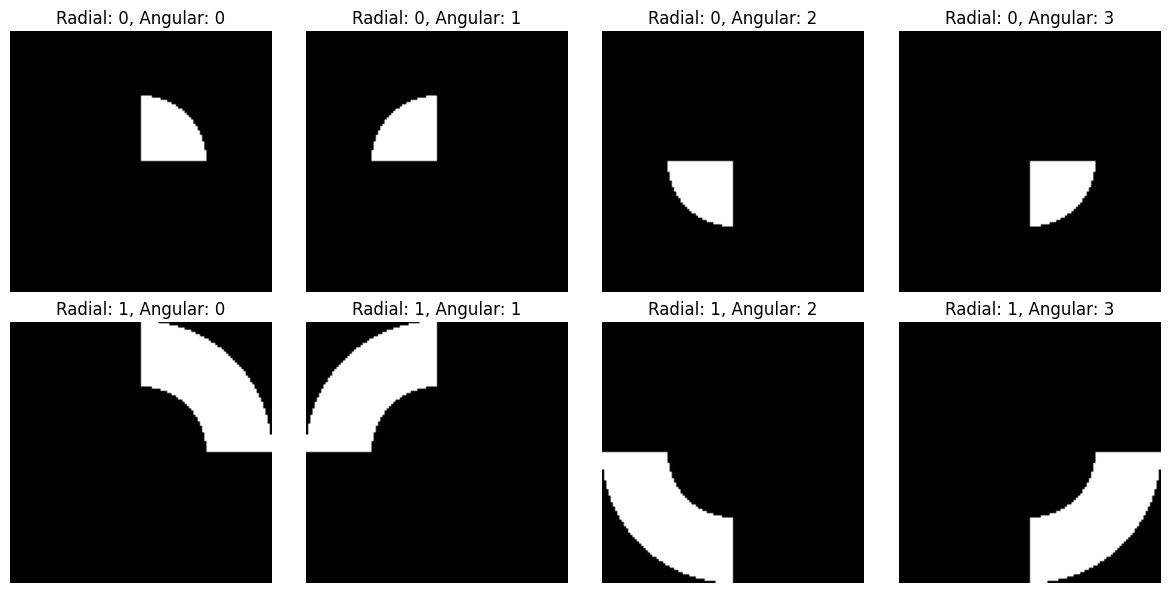

In [15]:
from src.cores.polar_description_vector import construct_sector
from shapely.affinity import rotate
from rasterio import features as rfeat

def construct_polar_kernels(radii: list[int], num_sectors: int) -> np.ndarray:
    """ Construct list of filters corresponding to each sector and radius. This will be used to convolve the original dbz map. """
    max_radii = radii[-1]
    origin = (max_radii, max_radii)

    kernels_lst = []
    prev_base_sector = None

    # Idea: travel through each radius, construct the sector for that radius by taking the 
    for r_idx, radius in enumerate(radii):
        new_sector = construct_sector(origin, radius, 0, 360/num_sectors)
        base_sector = new_sector if not prev_base_sector else new_sector.difference(prev_base_sector)
        
        prev_base_sector = new_sector
        
        for s_idx in range(num_sectors):
            sector = rotate(base_sector, s_idx * 360 / num_sectors, origin=origin)
            mask = rfeat.rasterize(shapes=[(sector, 1)], out_shape=(max_radii*2, max_radii*2), fill=0, masked=True, dtype=np.int8)

            kernels_lst.append(mask)

    return np.array(kernels_lst)

RADII = [30, 60]
NUM_SECTORS = 4

kernels = construct_polar_kernels(RADII, NUM_SECTORS)

# Plotting the kernels
fig, axes = plt.subplots(len(RADII), NUM_SECTORS, figsize=(12, 6))
for r_idx, radius in enumerate(RADII):
    for s_idx in range(NUM_SECTORS):
        ax = axes[r_idx, s_idx]
        kernel_idx = r_idx * NUM_SECTORS + s_idx
        ax.imshow(kernels[kernel_idx], cmap='gray')
        ax.set_title(f'Radial: {r_idx}, Angular: {s_idx}')
        # Reverse the y-axis to match Cartesian coordinates
        ax.invert_yaxis()
        ax.axis('off')
plt.tight_layout()
plt.show()